# Notebook 10 — Cancellation Analysis

**Tier:** 1 / 2 — Descriptive & Diagnostic  
**Purpose:** In-depth analysis of all cancellation types, reasons, trends and estimated impact.  
**Input:** `outputs/feature_store.parquet`  
**Output:** Charts in `outputs/plots/10_*`, tables in `outputs/reports/`

In [1]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
import sys, warnings, pathlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_parquet('outputs/feature_store.parquet')
completed = df[df['is_completed']].copy()
slot_order = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Loaded feature store: {df.shape}  |  completed: {len(completed):,}')

Loaded feature store: (150000, 46)  |  completed: 93,000


## 10.1 Overall Cancellation Landscape

In [2]:
n_total = len(df)
n_canc_c  = (df['Booking Status'] == 'Cancelled by Customer').sum()
n_canc_d  = (df['Booking Status'] == 'Cancelled by Driver').sum()
n_ndf     = (df['Booking Status'] == 'No Driver Found').sum()
n_incomplete = (df['Booking Status'] == 'Incomplete').sum()
n_failed  = n_canc_c + n_canc_d + n_ndf + n_incomplete

print(f'Total bookings              : {n_total:,}')
print(f'Overall failure rate        : {n_failed/n_total*100:.1f}%')
print(f'  Cancelled by Customer     : {n_canc_c:,}  ({n_canc_c/n_total*100:.1f}%)')
print(f'  Cancelled by Driver       : {n_canc_d:,}  ({n_canc_d/n_total*100:.1f}%)')
print(f'  No Driver Found           : {n_ndf:,}  ({n_ndf/n_total*100:.1f}%)')
print(f'  Incomplete                : {n_incomplete:,}  ({n_incomplete/n_total*100:.1f}%)')

Total bookings              : 150,000
Overall failure rate        : 38.0%
  Cancelled by Customer     : 10,500  (7.0%)
  Cancelled by Driver       : 27,000  (18.0%)
  No Driver Found           : 10,500  (7.0%)
  Incomplete                : 9,000  (6.0%)


## 10.2 Customer Cancellations

In [3]:
cust_canc = df[df['Booking Status'] == 'Cancelled by Customer'].copy()
print('Customer cancellation reasons:')
print(cust_canc['Reason for cancelling by Customer'].value_counts().to_string())
print()
print('Customer cancellation by Vehicle Type:')
print(cust_canc.groupby('Vehicle Type', observed=True).size().sort_values(ascending=False).to_string())

Customer cancellation reasons:
Reason for cancelling by Customer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155

Customer cancellation by Vehicle Type:
Vehicle Type
Auto             2680
Go Mini          2097
Go Sedan         1832
Bike             1575
Premier Sedan    1266
eBike             723
Uber XL           327


In [4]:
# VTAT at time of customer cancellation (is high VTAT driving cancellations?)
cc_vtat = cust_canc['Avg VTAT'].dropna()
all_vtat = df[df['Avg VTAT'].notna()]['Avg VTAT']
print(f'Avg VTAT for customer-cancelled rides : {cc_vtat.mean():.2f} min')
print(f'Avg VTAT for all dispatched rides     : {all_vtat.mean():.2f} min')
print(f'Difference                            : {cc_vtat.mean() - all_vtat.mean():+.2f} min')

Avg VTAT for customer-cancelled rides : 12.51 min
Avg VTAT for all dispatched rides     : 8.46 min
Difference                            : +4.06 min


Monthly customer cancellation rate (%):
month
1     6.9
2     7.0
3     7.1
4     6.4
5     7.2
6     7.1
7     7.2
8     6.6
9     7.3
10    7.1
11    7.0
12    7.1


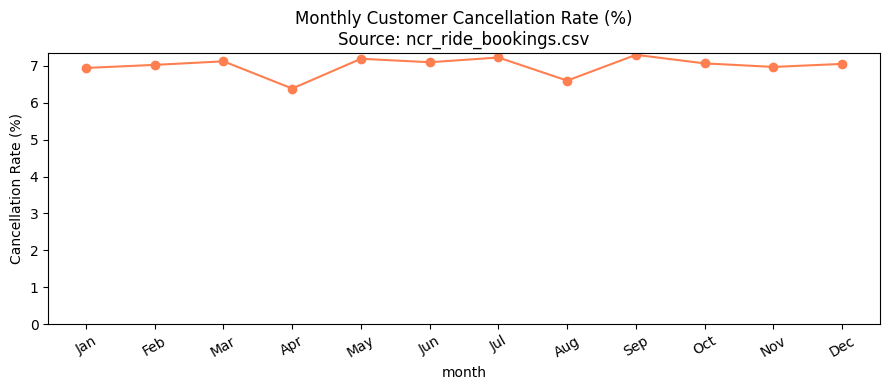

In [5]:
# Monthly customer cancellation rate trend
monthly_cc = df.groupby('month').apply(
    lambda g: (g['Booking Status'] == 'Cancelled by Customer').sum() / len(g) * 100
).rename('cust_canc_pct')
print('Monthly customer cancellation rate (%):')
print(monthly_cc.round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
monthly_cc.plot(marker='o', ax=ax, color='coral')
ax.set_title('Monthly Customer Cancellation Rate (%)\nSource: ncr_ride_bookings.csv')
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_labels, rotation=30)
ax.set_ylabel('Cancellation Rate (%)'); ax.set_ylim(0, None)
plt.tight_layout()
fig.savefig('outputs/plots/10_monthly_cust_canc.png', dpi=150, bbox_inches='tight')
plt.show()

## 10.3 Driver Cancellations

In [6]:
drv_canc = df[df['Booking Status'] == 'Cancelled by Driver'].copy()
print('Driver cancellation reasons:')
print(drv_canc['Driver Cancellation Reason'].value_counts().to_string())
print()
print('Driver cancellation by Vehicle Type:')
print(drv_canc.groupby('Vehicle Type', observed=True).size().sort_values(ascending=False).to_string())
print()
drv_slot = (drv_canc.groupby('time_slot', observed=True).size()
            .reindex([s for s in slot_order if s in df['time_slot'].cat.categories]))
print('Driver cancellation by Time Slot:')
print(drv_slot.to_string())

Driver cancellation reasons:
Driver Cancellation Reason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there    6686

Driver cancellation by Vehicle Type:
Vehicle Type
Auto             6643
Go Mini          5330
Go Sedan         5031
Bike             4077
Premier Sedan    3250
eBike            1907
Uber XL           762

Driver cancellation by Time Slot:
time_slot
Early Morning    1755
Morning          6133
Afternoon        5027
Evening          9458
Night            4141
Late Night        486


## 10.4 Cancellation Revenue Impact Estimate

In [7]:
median_fare = completed['Booking Value'].median()
avg_fare    = completed['Booking Value'].mean()

# Upper-bound scenario: ALL cancelled rides would have completed at average fare
scenario_upper = (n_canc_c + n_canc_d) * avg_fare

print(f'Avg fare (completed rides)   : ₹{avg_fare:,.0f}')
print(f'Median fare (completed rides): ₹{median_fare:,.0f}')
print()
print(f'Total cancelled bookings (Customer + Driver): {n_canc_c + n_canc_d:,}')
print()
print(f'Revenue impact SCENARIO (if all cancelled → completed at avg fare):')
print(f'  ₹{scenario_upper:,.0f}')
print()
print('⚠ WARNING: This is a hypothetical upper-bound SCENARIO ESTIMATE only.')
print('   It assumes every cancelled ride would have completed at average fare,')
print('   which is not guaranteed. Actual recoverable revenue would be lower.')
print('   Net revenue cannot be estimated — no cost data available.')

Avg fare (completed rides)   : ₹508
Median fare (completed rides): ₹414

Total cancelled bookings (Customer + Driver): 37,500

Revenue impact SCENARIO (if all cancelled → completed at avg fare):
  ₹19,056,683

⚠ WARNING: This is a hypothetical upper-bound SCENARIO ESTIMATE only.
   It assumes every cancelled ride would have completed at average fare,
   which is not guaranteed. Actual recoverable revenue would be lower.
   Net revenue cannot be estimated — no cost data available.


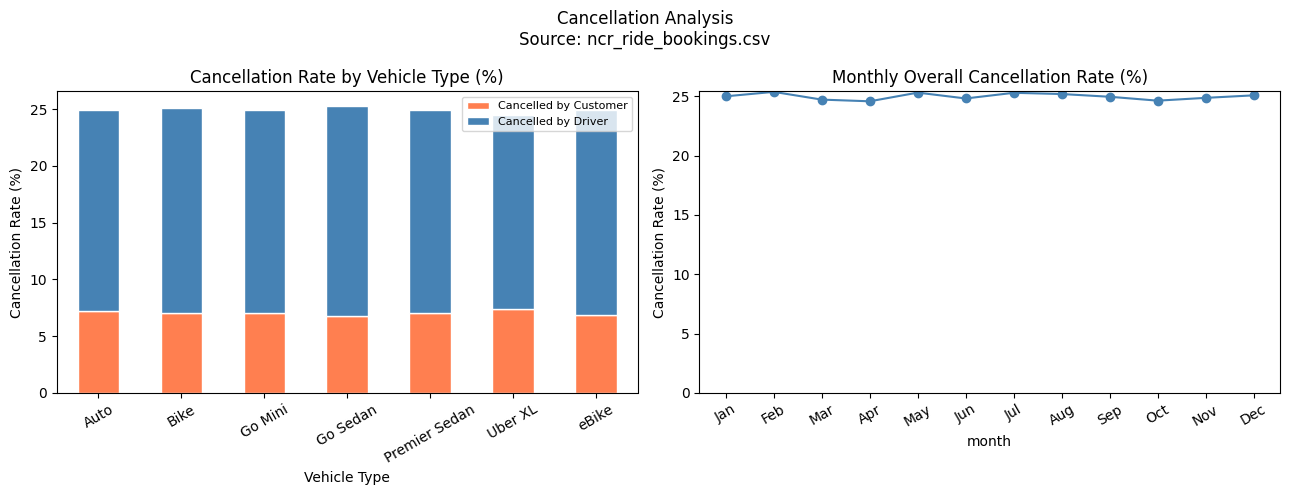

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cancellation rate by vehicle type (stacked by party)
vc = df.groupby('Vehicle Type', observed=True).agg(
    canc_cust=('Booking Status', lambda s: (s=='Cancelled by Customer').sum()),
    canc_drv=('Booking Status', lambda s: (s=='Cancelled by Driver').sum()),
    total=('Booking ID','count')
)
vc[['canc_cust','canc_drv']].div(vc['total'], axis=0).mul(100).plot(
    kind='bar', stacked=True, ax=axes[0], color=['coral','steelblue'], edgecolor='white')
axes[0].set_title('Cancellation Rate by Vehicle Type (%)')
axes[0].set_ylabel('Cancellation Rate (%)'); axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(['Cancelled by Customer','Cancelled by Driver'], fontsize=8)

# Monthly overall cancellation rate
monthly_all_canc = df.groupby('month').apply(
    lambda g: g['is_cancelled'].sum() / len(g) * 100).rename('canc_pct')
monthly_all_canc.plot(marker='o', ax=axes[1], color='steelblue')
axes[1].set_title('Monthly Overall Cancellation Rate (%)')
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(month_labels, rotation=30)
axes[1].set_ylabel('Cancellation Rate (%)'); axes[1].set_ylim(0, None)

fig.suptitle('Cancellation Analysis\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/10_cancellation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Limitations
- No driver ID — cannot attribute driver cancellations to specific repeat offenders.
- Revenue impact estimate is a hypothetical upper-bound scenario, not a forecast.
- No cost data → cannot estimate net margin impact of cancellations.